# Bitcoin vs Gold Volatility Comparison

## Financial Risk & Volatility Analysis Using Python

This project compares the return, risk, and volatility characteristics of Bitcoin and Gold using statistical and quantitative finance techniques.

### Main Objectives
- Compare historical price behavior
- Calculate and compare log returns
- Analyze descriptive statistics
- Test return stationarity
- Compare annualized and rolling volatility
- Analyze correlation
- Model conditional volatility using GARCH
- Compare Value at Risk (VaR)

# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from arch import arch_model

import warnings
warnings.filterwarnings("ignore")

# DataFrame Display Settings

In [8]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format",lambda x: f"{x:,.6f}")

## 1. Data Collection

Historical daily market data will be collected for:

- **Bitcoin:** BTC-USD
- **Gold Futures:** GC=F

The same time period will be used for both assets to ensure a consistent comparison.

In [5]:
BTC_TICKER = "BTC-USD"
GOLD_TICKER = "GC=F"

START_DATE = "2020-01-01"
END_DATE = "2026-09-01"

## 2. Download Historical Data

Historical daily prices are downloaded from Yahoo Finance for Bitcoin and Gold.

In [6]:
btc = yf.download(
    BTC_TICKER,
    start = START_DATE,
    end = END_DATE,
    auto_adjust = True
)

gold = yf.download(
    GOLD_TICKER,
    start = START_DATE,
    end = END_DATE,
    auto_adjust = True
)

print("Bitcoin Shape:", btc.shape)
print("Gold Shape:" , gold.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Bitcoin Shape: (2435, 5)
Gold Shape: (1677, 5)


## Data Inspection

Review the first observations and verify successful data collection.

In [9]:
btc.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,"7,200.174316","7,254.330566","7,174.944336","7,194.892090",18565664997
2020-01-02,"6,985.470215","7,212.155273","6,935.270020","7,202.551270",20802083465
2020-01-03,"7,344.884277","7,413.715332","6,914.996094","6,984.428711",28111481032
2020-01-04,"7,410.656738","7,427.385742","7,309.514160","7,345.375488",18444271275
2020-01-05,"7,411.317383","7,544.497070","7,400.535645","7,410.451660",19725074095


In [10]:
gold.head()

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2020-01-02,"1,524.500000","1,528.699951","1,518.000000","1,518.099976",214
2020-01-03,"1,549.199951","1,552.699951","1,530.099976","1,530.099976",107
2020-01-06,"1,566.199951","1,580.000000","1,560.400024","1,580.000000",416
2020-01-07,"1,571.800049","1,576.300049","1,558.300049","1,558.300049",47
2020-01-08,"1,557.400024","1,604.199951","1,552.300049","1,579.699951",236


## Missing Values Check

Before analysis, verify data quality and identify any missing observations.

In [11]:
print("Bitcoin Missing Values")
print(btc.isnull().sum())

print("\nGold Missing Values")
print(gold.isnull().sum())

Bitcoin Missing Values
Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

Gold Missing Values
Price   Ticker
Close   GC=F      0
High    GC=F      0
Low     GC=F      0
Open    GC=F      0
Volume  GC=F      0
dtype: int64


## Extract Closing Prices

Only adjusted closing prices are retained for return calculations.

In [13]:
btc_price = btc[["Close"]].copy()
gold_price = gold[["Close"]].copy()

btc_price.columns = ["BTC_Close"]
gold_price.columns = ["Gold_Close"]

## Merge Datasets

Combine Bitcoin and Gold prices into a single DataFrame for comparison.

In [14]:
prices = pd.concat(
    [btc_price, gold_price ],
    axis= 1
)

prices.head()

,BTC_Close,Gold_Close
Date,,
2020-01-01,"7,200.174316",NaN
2020-01-02,"6,985.470215","1,524.500000"
2020-01-03,"7,344.884277","1,549.199951"
2020-01-04,"7,410.656738",NaN
2020-01-05,"7,411.317383",NaN


In [15]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2435 entries, 2020-01-01 to 2026-08-31
Freq: D
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BTC_Close   2435 non-null   float64
 1   Gold_Close  1677 non-null   float64
dtypes: float64(2)
memory usage: 57.1 KB


In [16]:
prices.describe()

,BTC_Close,Gold_Close
count,"2,435.000000","1,677.000000"
mean,"49,687.813830","2,437.724687"
std,"30,871.146844",949.287282
min,"4,970.788086","1,477.300049"
25%,"23,689.988281","1,808.500000"
50%,"43,613.140625","1,954.199951"
75%,"68,294.933594","2,738.399902"
max,"124,752.531250","5,318.399902"


## Price Comparison

Visual comparison of Bitcoin and Gold price movements over time.

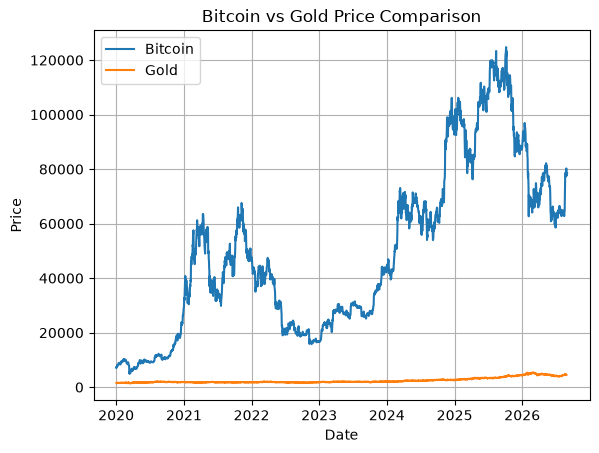

In [24]:
plt.Figure(figsize=(12,6))

plt.plot(prices.index, prices["BTC_Close"], label = "Bitcoin")
plt.plot(prices.index, prices["Gold_Close"], label = "Gold")

plt.title("Bitcoin vs Gold Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

## 3. Trading Day Alignment

Bitcoin trades every day, while Gold trades only on market days.

To ensure a fair comparison, only common trading dates are retained.

In [25]:
returns_data = prices.dropna()
returns_data.shape

(1677, 2)

## Log Return Calculation

Log returns are used because they are widely applied in financial time-series analysis and volatility modeling.

In [29]:
returns_data["BTC_Return"] = np.log(
    returns_data["BTC_Close"] /
    returns_data["BTC_Close"].shift(1)
)

returns_data["Gold_Return"] = np.log(
        returns_data["Gold_Close"] /
    returns_data["Gold_Close"].shift(1)
)

In [30]:
returns_data = returns_data.dropna()
returns_data.head()

,BTC_Close,Gold_Close,BTC_Return,Gold_Returns,Gold_Return
Date,,,,,
2020-01-06,"7,769.219238","1,566.199951",0.056166,0.010914,0.010914
2020-01-07,"8,163.692383","1,571.800049",0.049527,0.003569,0.003569
2020-01-08,"8,079.862793","1,557.400024",-0.010322,-0.009204,-0.009204
2020-01-09,"7,879.071289","1,551.699951",-0.025165,-0.003667,-0.003667
2020-01-10,"8,166.554199","1,557.500000",0.035837,0.003731,0.003731


## Return Series Overview

Inspect the first observations of Bitcoin and Gold log returns.

In [31]:
returns_data[
    ["BTC_Return" , "Gold_Return"]
].head()

,BTC_Return,Gold_Return
Date,,
2020-01-06,0.056166,0.010914
2020-01-07,0.049527,0.003569
2020-01-08,-0.010322,-0.009204
2020-01-09,-0.025165,-0.003667
2020-01-10,0.035837,0.003731


## 4. Descriptive Statistics

Summary statistics provide insight into return behavior and risk characteristics.

In [32]:
def descriptive_stats(series):

    return pd.Series({
        "Mean": series.mean(),
        "Std Dev": series.std(),
        "Min": series.min(),
        "Max": series.max(),
        "Skewness": series.skew(),
        "Kurtosis": series.kurtosis()
    })

In [33]:
btc_stats = descriptive_stats(
    returns_data["BTC_Return"]
)

btc_stats

Mean        0.001415
Std Dev     0.038347
Min        -0.464730
Max         0.191527
Skewness   -1.188064
Kurtosis   16.369169
dtype: float64

In [34]:
gold_stats = descriptive_stats(
    returns_data["Gold_Return"]
)

gold_stats

Mean        0.000634
Std Dev     0.012083
Min        -0.114060
Max         0.058926
Skewness   -0.763587
Kurtosis    7.380439
dtype: float64

## Comparative Statistics Table

In [35]:
stats_table = pd.concat(
    [btc_stats, gold_stats],
    axis=1
)

stats_table.columns = [
    "Bitcoin",
    "Gold"
]

stats_table

,Bitcoin,Gold
Mean,0.001415,0.000634
Std Dev,0.038347,0.012083
Min,-0.464730,-0.114060
Max,0.191527,0.058926
Skewness,-1.188064,-0.763587
Kurtosis,16.369169,7.380439


## 5. Annualized Volatility

Annualized volatility measures the expected fluctuation of returns over one year.

In [36]:
btc_vol = (
    returns_data["BTC_Return"].std()
    * np.sqrt(252)
)

gold_vol = (
    returns_data["Gold_Return"].std()
    * np.sqrt(252)
)

print(
    f"Bitcoin Annualized Volatility: {btc_vol:.2%}"
)

print(
    f"Gold Annualized Volatility: {gold_vol:.2%}"
)

Bitcoin Annualized Volatility: 60.87%
Gold Annualized Volatility: 19.18%


In [37]:
volatility_table = pd.DataFrame({
    "Asset": ["Bitcoin", "Gold"],
    "Annualized Volatility": [
        btc_vol,
        gold_vol
    ]
})

volatility_table

,Asset,Annualized Volatility
0,Bitcoin,0.608743
1,Gold,0.191811


## Volatility Comparison

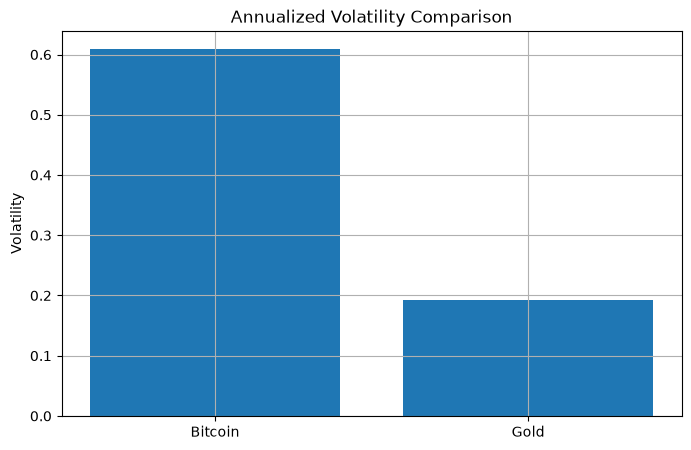

In [38]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Bitcoin", "Gold"],
    [btc_vol, gold_vol]
)

plt.title(
    "Annualized Volatility Comparison"
)

plt.ylabel("Volatility")

plt.grid(True)

plt.show()

## 6. Stationarity Test

The Augmented Dickey-Fuller (ADF) test is used to determine whether a time series is stationary.

### Hypotheses

- H0: Series is non-stationary
- H1: Series is stationary

In [39]:
def adf_test(series, asset_name):

    result = adfuller(series)

    print(f"\nADF Test - {asset_name}")
    print("-" * 40)

    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"P-Value: {result[1]:.4f}")

    if result[1] < 0.05:
        print("Result: Stationary")
    else:
        print("Result: Non-Stationary")

In [40]:
adf_test(
    returns_data["BTC_Return"],
    "Bitcoin Returns"
)


ADF Test - Bitcoin Returns
----------------------------------------
ADF Statistic: -14.9025
P-Value: 0.0000
Result: Stationary


In [41]:
adf_test(
    returns_data["Gold_Return"],
    "Gold Returns"
)


ADF Test - Gold Returns
----------------------------------------
ADF Statistic: -17.7342
P-Value: 0.0000
Result: Stationary


## 7. Rolling Volatility

Rolling volatility measures how risk changes over time.

A 30-day rolling window is used.

In [42]:
returns_data["BTC_Rolling_Vol"] = (
    returns_data["BTC_Return"]
    .rolling(30)
    .std()
    * np.sqrt(252)
)

returns_data["Gold_Rolling_Vol"] = (
    returns_data["Gold_Return"]
    .rolling(30)
    .std()
    * np.sqrt(252)
)

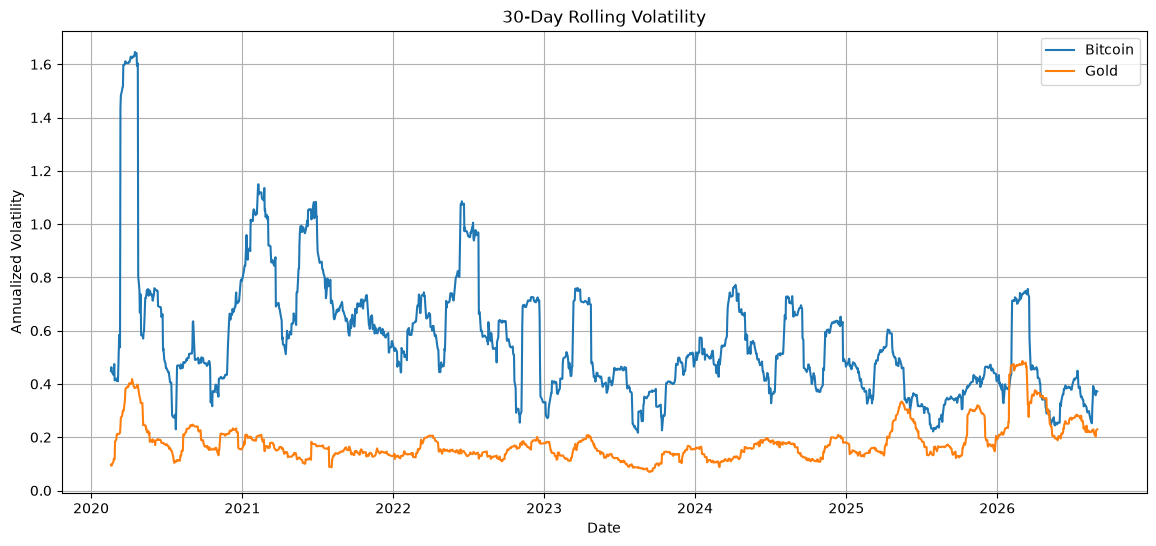

In [43]:
plt.figure(figsize=(14,6))

plt.plot(
    returns_data.index,
    returns_data["BTC_Rolling_Vol"],
    label="Bitcoin"
)

plt.plot(
    returns_data.index,
    returns_data["Gold_Rolling_Vol"],
    label="Gold"
)

plt.title(
    "30-Day Rolling Volatility"
)

plt.ylabel("Annualized Volatility")
plt.xlabel("Date")

plt.legend()
plt.grid(True)

plt.show()

## 8. Return Distribution

Comparing return distributions helps identify differences in risk and tail behavior.

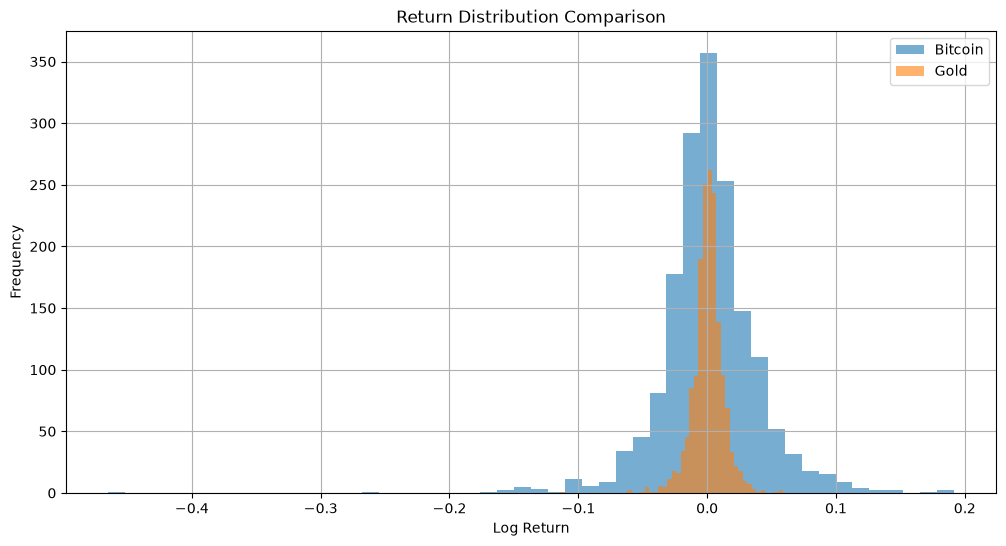

In [44]:
plt.figure(figsize=(12,6))

plt.hist(
    returns_data["BTC_Return"],
    bins=50,
    alpha=0.6,
    label="Bitcoin"
)

plt.hist(
    returns_data["Gold_Return"],
    bins=50,
    alpha=0.6,
    label="Gold"
)

plt.title(
    "Return Distribution Comparison"
)

plt.xlabel("Log Return")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()

In [45]:
rolling_summary = pd.DataFrame({
    "Asset": ["Bitcoin", "Gold"],
    "Average Rolling Volatility": [
        returns_data["BTC_Rolling_Vol"].mean(),
        returns_data["Gold_Rolling_Vol"].mean()
    ]
})

rolling_summary

,Asset,Average Rolling Volatility
0,Bitcoin,0.561652
1,Gold,0.178688


## Risk Ratio

How many times is Bitcoin more volatile than Gold?

In [46]:
risk_ratio = (
    returns_data["BTC_Rolling_Vol"].mean()
    /
    returns_data["Gold_Rolling_Vol"].mean()
)

print(
    f"Bitcoin is approximately {risk_ratio:.2f} times more volatile than Gold."
)

Bitcoin is approximately 3.14 times more volatile than Gold.


## 9. Correlation Analysis

Correlation measures the degree to which Bitcoin and Gold returns move together.

A value close to:
- +1 indicates strong positive correlation
- 0 indicates little or no linear relationship
- -1 indicates strong negative correlation

In [47]:
correlation = returns_data[
    ["BTC_Return", "Gold_Return"]
].corr()

correlation

,BTC_Return,Gold_Return
BTC_Return,1.000000,0.117999
Gold_Return,0.117999,1.000000


In [48]:
btc_gold_corr = returns_data[
    "BTC_Return"
].corr(
    returns_data["Gold_Return"]
)

print(
    f"Bitcoin-Gold Correlation: {btc_gold_corr:.4f}"
)

Bitcoin-Gold Correlation: 0.1180


## Correlation Matrix Visualization

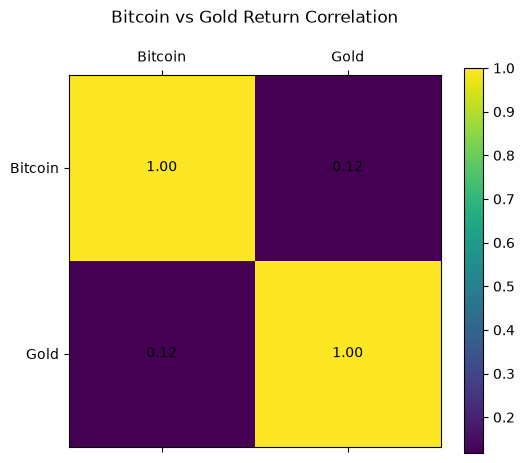

In [50]:
fig, ax = plt.subplots(figsize=(6,5))

cax = ax.matshow(correlation)

fig.colorbar(cax)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))

ax.set_xticklabels(
    ["Bitcoin", "Gold"]
)

ax.set_yticklabels(
    ["Bitcoin", "Gold"]
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        ax.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title(
    "Bitcoin vs Gold Return Correlation",
    pad=20
)

plt.show()

## 10. GARCH Volatility Modeling

The GARCH(1,1) model is used to estimate time-varying conditional volatility.

It captures volatility clustering, where periods of high volatility tend to be followed by high volatility, and periods of low volatility tend to be followed by low volatility.

In [51]:
btc_garch_returns = (
    returns_data["BTC_Return"]
    * 100
)

gold_garch_returns = (
    returns_data["Gold_Return"]
    * 100
)

### Bitcoin GARCH(1,1)

In [52]:
btc_garch_model = arch_model(
    btc_garch_returns,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

btc_garch_result = btc_garch_model.fit(
    disp="off"
)

print(
    btc_garch_result.summary()
)

                       Zero Mean - GARCH Model Results                        
Dep. Variable:             BTC_Return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -4527.79
Distribution:                  Normal   AIC:                           9061.57
Method:            Maximum Likelihood   BIC:                           9077.84
                                        No. Observations:                 1675
Date:                Sat, Sep 19 2026   Df Residuals:                     1675
Time:                        14:04:15   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.8580      0.380      2.255  2.413e-02   [  0.11

### Gold GARCH(1,1)

In [53]:
gold_garch_model = arch_model(
    gold_garch_returns,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

gold_garch_result = gold_garch_model.fit(
    disp="off"
)

print(
    gold_garch_result.summary()
)

                       Zero Mean - GARCH Model Results                        
Dep. Variable:            Gold_Return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -2561.22
Distribution:                  Normal   AIC:                           5128.43
Method:            Maximum Likelihood   BIC:                           5144.70
                                        No. Observations:                 1675
Date:                Sat, Sep 19 2026   Df Residuals:                     1675
Time:                        14:04:33   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0560  2.529e-02      2.216  2.669e-02 [6.476e-0

In [54]:
returns_data["BTC_GARCH_Vol"] = (
    btc_garch_result.conditional_volatility
)

returns_data["Gold_GARCH_Vol"] = (
    gold_garch_result.conditional_volatility
)

## Conditional Volatility Comparison

The estimated conditional volatility series shows how market risk evolves over time according to the GARCH model.

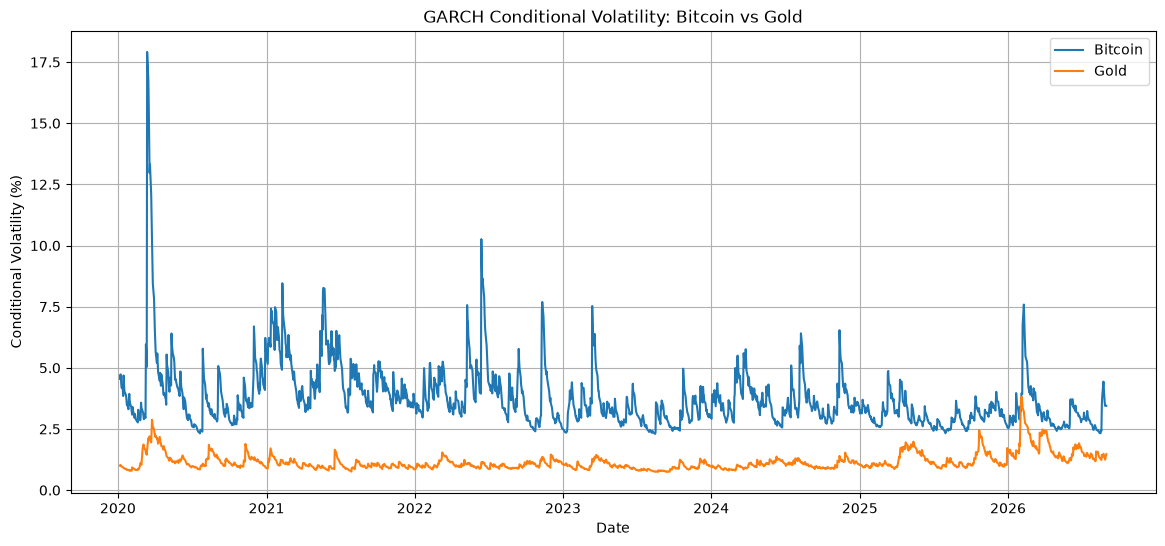

In [55]:
plt.figure(figsize=(14,6))

plt.plot(
    returns_data.index,
    returns_data["BTC_GARCH_Vol"],
    label="Bitcoin"
)

plt.plot(
    returns_data.index,
    returns_data["Gold_GARCH_Vol"],
    label="Gold"
)

plt.title(
    "GARCH Conditional Volatility: Bitcoin vs Gold"
)

plt.xlabel("Date")
plt.ylabel("Conditional Volatility (%)")

plt.legend()
plt.grid(True)

plt.show()

In [56]:
garch_summary = pd.DataFrame({
    "Asset": [
        "Bitcoin",
        "Gold"
    ],
    "Average GARCH Volatility (%)": [
        returns_data["BTC_GARCH_Vol"].mean(),
        returns_data["Gold_GARCH_Vol"].mean()
    ]
})

garch_summary

,Asset,Average GARCH Volatility (%)
0,Bitcoin,3.773329
1,Gold,1.157982


## Volatility Persistence

In a GARCH(1,1) model, volatility persistence is measured by:

**Persistence = Alpha + Beta**

Values close to 1 indicate that volatility shocks decay slowly over time.

In [58]:
btc_alpha = btc_garch_result.params["alpha[1]"]
btc_beta = btc_garch_result.params["beta[1]"]

gold_alpha = gold_garch_result.params["alpha[1]"]
gold_beta = gold_garch_result.params["beta[1]"]

btc_persistence = btc_alpha + btc_beta
gold_persistence = gold_alpha + gold_beta

print(
    f"Bitcoin Volatility Persistence: "
    f"{btc_persistence:.4f}"
)

print(
    f"Gold Volatility Persistence: "
    f"{gold_persistence:.4f}"
)

Bitcoin Volatility Persistence: 0.9571
Gold Volatility Persistence: 0.9625


In [59]:
garch_parameters = pd.DataFrame({
    "Parameter": [
        "Omega",
        "Alpha",
        "Beta",
        "Persistence"
    ],
    
    "Bitcoin": [
        btc_garch_result.params["omega"],
        btc_alpha,
        btc_beta,
        btc_persistence
    ],
    
    "Gold": [
        gold_garch_result.params["omega"],
        gold_alpha,
        gold_beta,
        gold_persistence
    ]
})

garch_parameters

,Parameter,Bitcoin,Gold
0,Omega,0.857979,0.056039
1,Alpha,0.138589,0.088849
2,Beta,0.818522,0.873660
3,Persistence,0.957112,0.962509


## 11. Risk Metrics

Two widely used downside risk measures are:

### Value at Risk (VaR)

The maximum expected loss at a given confidence level over a specific period.

### Expected Shortfall (ES)

The average loss when losses exceed the VaR threshold.

This measure is often considered more informative than VaR because it captures tail risk.

In [60]:
btc_var_95 = returns_data[
    "BTC_Return"
].quantile(0.05)

gold_var_95 = returns_data[
    "Gold_Return"
].quantile(0.05)

print(
    f"Bitcoin VaR (95%): {btc_var_95:.4%}"
)

print(
    f"Gold VaR (95%): {gold_var_95:.4%}"
)

Bitcoin VaR (95%): -5.4713%
Gold VaR (95%): -1.8691%


In [61]:
btc_es_95 = returns_data[
    returns_data["BTC_Return"] <= btc_var_95
]["BTC_Return"].mean()

gold_es_95 = returns_data[
    returns_data["Gold_Return"] <= gold_var_95
]["Gold_Return"].mean()

print(
    f"Bitcoin ES (95%): {btc_es_95:.4%}"
)

print(
    f"Gold ES (95%): {gold_es_95:.4%}"
)

Bitcoin ES (95%): -8.9624%
Gold ES (95%): -2.9202%


## Risk Metrics Comparison

In [62]:
risk_metrics = pd.DataFrame({

    "Metric": [
        "VaR 95%",
        "Expected Shortfall 95%"
    ],

    "Bitcoin": [
        btc_var_95,
        btc_es_95
    ],

    "Gold": [
        gold_var_95,
        gold_es_95
    ]
})

risk_metrics

,Metric,Bitcoin,Gold
0,VaR 95%,-0.054713,-0.018691
1,Expected Shortfall 95%,-0.089624,-0.029202


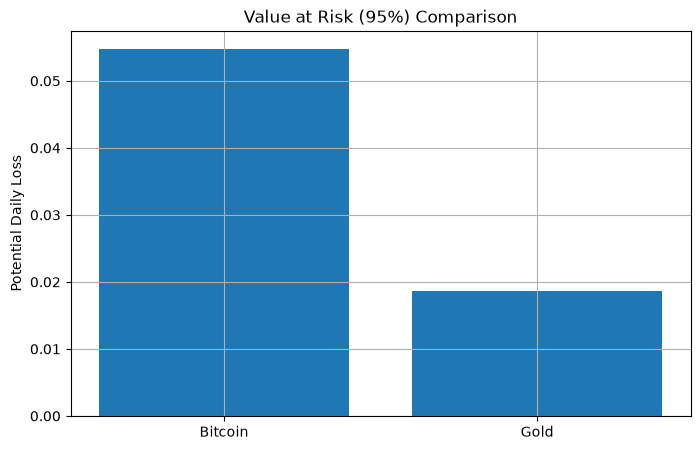

In [63]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Bitcoin", "Gold"],
    [abs(btc_var_95), abs(gold_var_95)]
)

plt.title(
    "Value at Risk (95%) Comparison"
)

plt.ylabel("Potential Daily Loss")

plt.grid(True)

plt.show()

In [65]:
risk_ratio_var = (
    abs(btc_var_95)
    /
    abs(gold_var_95)
)

risk_ratio_es = (
    abs(btc_es_95)
    /
    abs(gold_es_95)
)

print(
    f"Bitcoin VaR is {risk_ratio_var:.2f} times larger than Gold."
)

print(
    f"Bitcoin Expected Shortfall is {risk_ratio_es:.2f} times larger than Gold."
)

Bitcoin VaR is 2.93 times larger than Gold.
Bitcoin Expected Shortfall is 3.07 times larger than Gold.


## Export Summary Tables

In [66]:
stats_table.to_csv(
    "../outputs/tables/descriptive_statistics.csv"
)

volatility_table.to_csv(
    "../outputs/tables/volatility_metrics.csv"
)

risk_metrics.to_csv(
    "../outputs/tables/risk_metrics.csv"
)

garch_parameters.to_csv(
    "../outputs/tables/garch_parameters.csv"
)

print("Tables exported successfully.")

Tables exported successfully.


In [67]:
plt.savefig(
    "../outputs/figures/figure_name.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>